In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# 1.- EXPLORATORY DATA ANALYSIS
## 1.1- Load data from data base

In [2]:
cwd = os.getcwd()
dp = os.path.dirname(cwd)
df_raw = pd.read_csv(dp+'\data\Telco-Customer-Churn.csv')
df = df_raw.copy(deep=True)
print(f"DataFrame shape: {df_raw.shape[0]} samples, {df_raw.shape[1]} variables")

DataFrame shape: 7043 samples, 21 variables


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TotalCharges shows NaN for several statistics. We will look into it in the following section. 

## 1.2.- Checking data quality
###  1.2.1- Null and duplicated values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


As we can verify in the "Non-Null Count" column, there aren't any null values in the DataFrame.

Checking for duplicated rows:

In [6]:
df.duplicated().sum()

np.int64(0)

Next, we must check whether there is any variable that requires unique values and, if so, verify that this condition is met. In our DataFrame we need to check *customerID*.

In [7]:
df["customerID"].duplicated().sum()

np.int64(0)

### 1.2.2- Data types

Verify that every variable has the correct data type:

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

- Most type=object features are binary, we will encode them later to 0\\1 values. The variables with 3 or more categories will be encoded using OneHotEncoder.
- On the other hand, we notice that **TotalCharges** should be type=float, but it appears as an object. As we checked in df.info() there is no NaN values in that column, so therefore there must be some empty or blank strings in one or several rows.

In [9]:
(df['TotalCharges'] == '').sum()

np.int64(0)

In [10]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [11]:
print(df[df['TotalCharges'] == ' '])

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  \
488            No  No phone service             DSL                  Yes   
753    

We have 11 empty values and each of these customers have a **tenure** = 0, meaning that they are new customers that have stayed with the company for less than a month. Therefore we decide to write their **TotalCharges** as 0.

In [12]:
df['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In this particular data set, every numerical variable value must be positive or zero:

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
i = 0
for f in num_cols:
    a = (df[num_cols[i]]<0).sum()
    if a != 0:
        print(f"Invalid feature {f} value: {a}")
        i+=1
if i == 0: print("All numerical features values are valid")

All numerical features values are valid


## 1.3.- Visualize data & explore
### 1.3.1- Checking target distribution
Target **Churn** is a binary variable.

In [14]:
print(f"Target values count: \n{df['Churn'].value_counts()}")
print(f"\nTarget values count percentage: \n{df['Churn'].value_counts(normalize=True) * 100}%")

Target values count: 
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target values count percentage: 
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64%


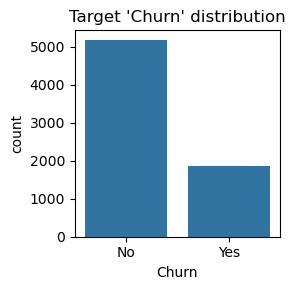

In [15]:
plt.figure(figsize=(3,3))
sns.countplot(data=df,x="Churn")
plt.title("Target 'Churn' distribution")
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\01_target_distribution.png')
plt.show()

Target values are **not** well balanced. We will have to be careful with the *accuracy* metric when building the model, since per example a model that always predicts "No" will have an accuracy of 73%, and take into account other metrics such as *recall*.

## 3.2 Features

- **Seniorcitizen** appears as a numerical binary variable
- We will drop **customerID** as it has no value in our dataset for modeling purposes.

In [16]:
df = df.drop('customerID',axis = 1)

In [17]:
num_cols = ['tenure','MonthlyCharges','TotalCharges']
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'] #w/o the target

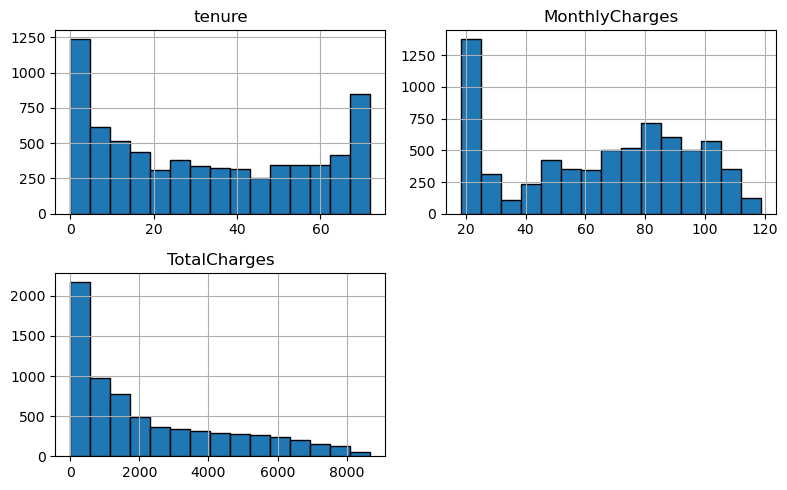

In [18]:
df[num_cols].hist(figsize=(8,5), bins=15, edgecolor='black', linewidth=1)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\02_numerical_distribution.png')
plt.show()

- There are a lot of new customers in the last month and also a significant number that have stayed in the company for a long period of time (+60 mo).
- Most montly charges are concentrated under 30€, after that quantity the charges follow almost a normal distribution.

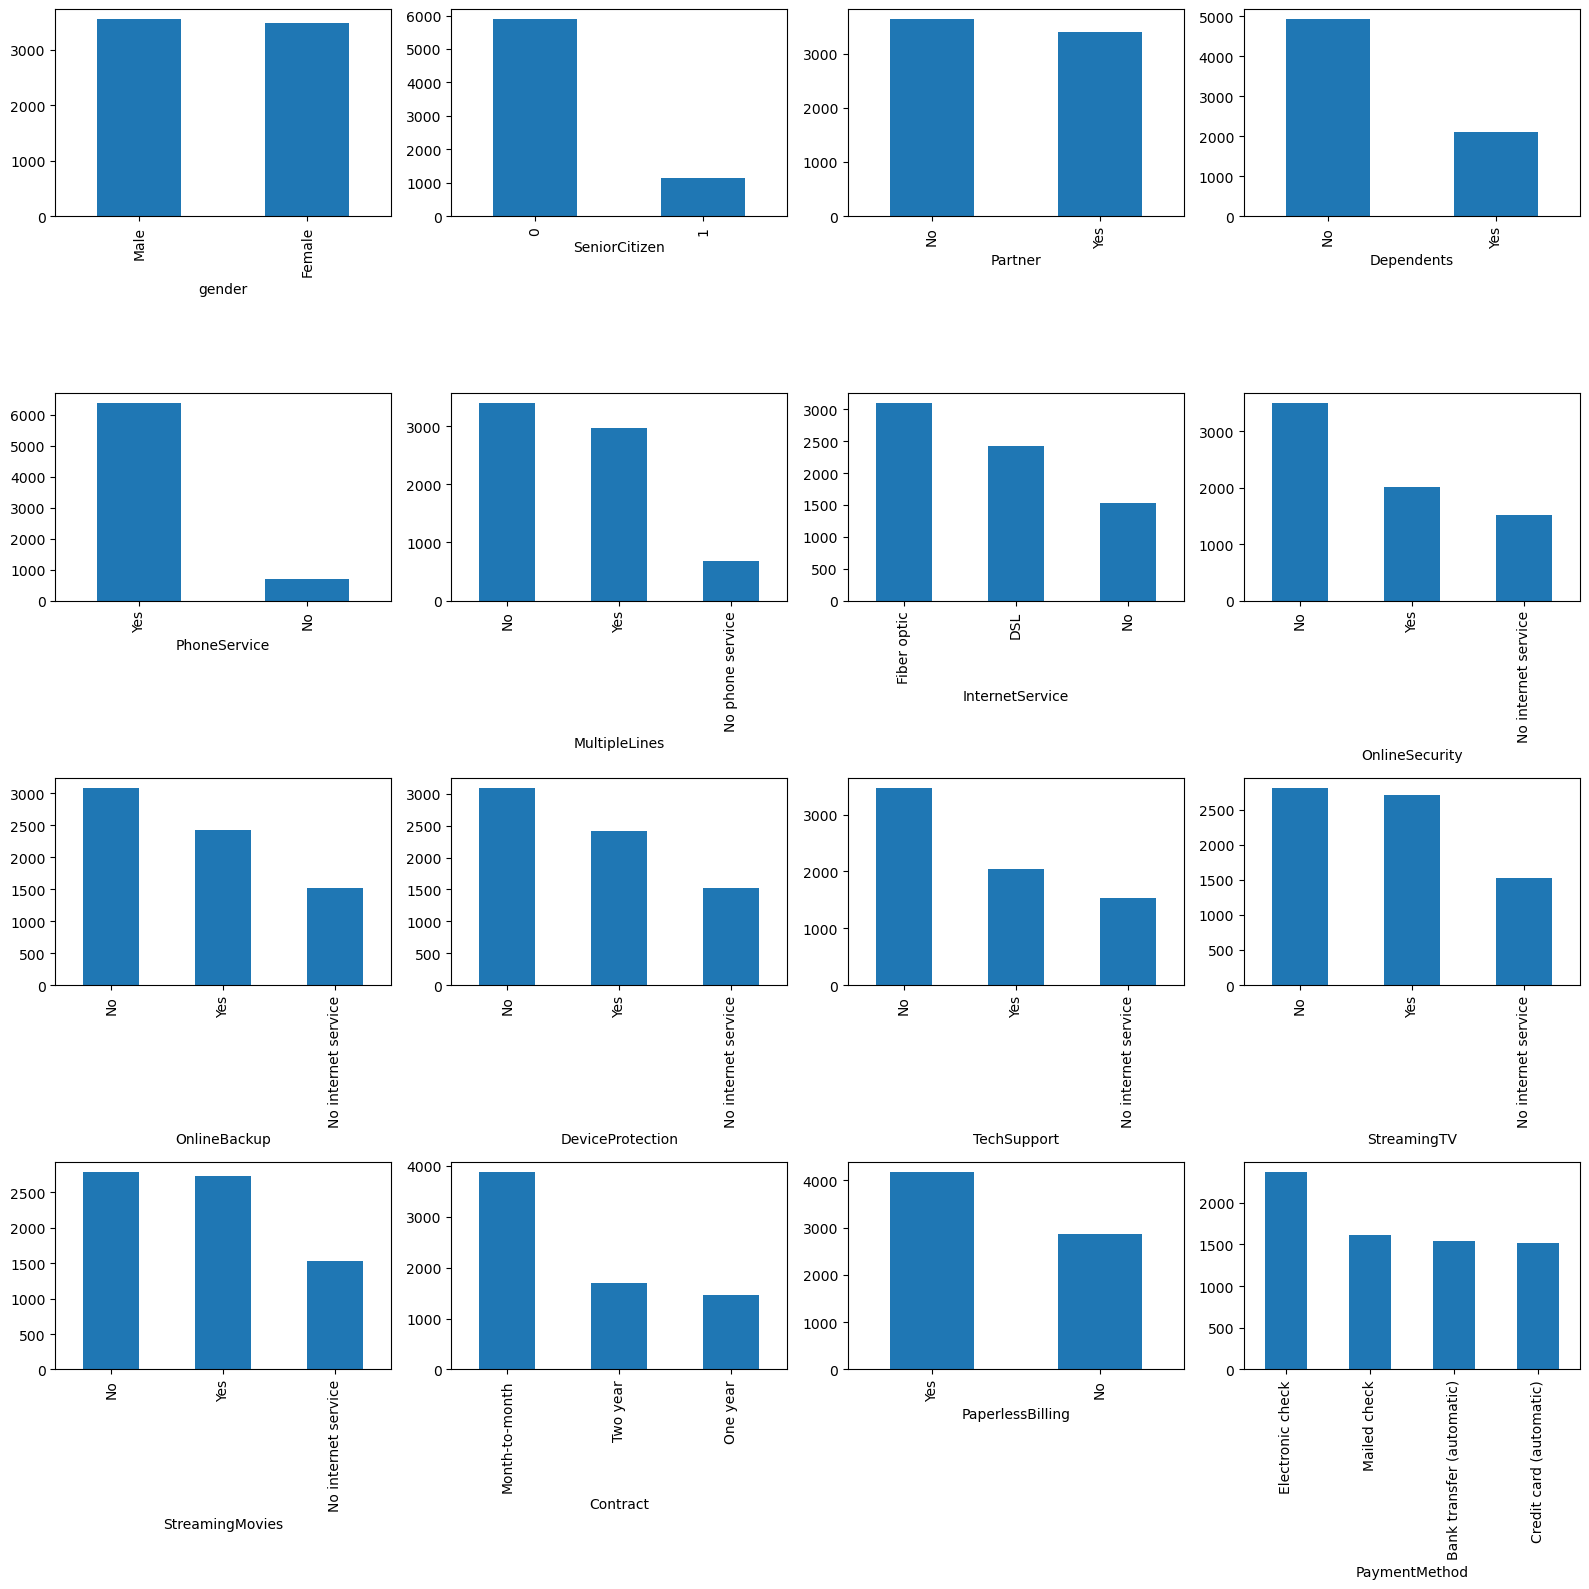

In [19]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))  
axes_iterator = iter(axes.ravel()) 

for col in cat_cols:
    curr_ax = next(axes_iterator) 
    df[col].value_counts().plot(kind='bar', ax=curr_ax)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\03_categorical_distribution.png')
plt.show()

- **Gender**, **partner**, **MultipleLines**, **StreamingTV** and **StreamingMovies** (not taking into account people w/o phone service) are well balanced.
- Most customers are not senior citizens
- Most contracts are Month-to-month rather than yearly or biennial.
- Preferred **PaymentMethod** is Electronic Check

## 3.3 Comparing features and target

### 3.3.1 Numerical

**TENURE**

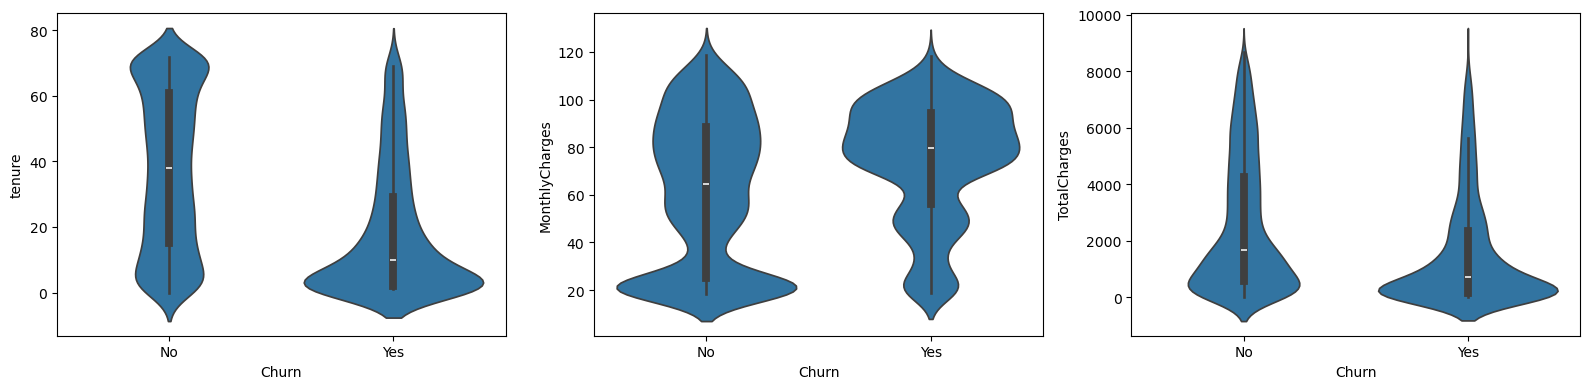

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  
axes_iterator = iter(axes.ravel()) 

for col in num_cols:
    curr_ax = next(axes_iterator) 
    sns.violinplot(data = df, x = 'Churn', y = col, ax=curr_ax)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\04_numerical_vs_target.png')
plt.show()

In [21]:
df.groupby("Churn")[num_cols].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


- The violin plot indicates that a higher number of lower tenure customers have cancelled the subscription, meaning that frequently new customers cancel their subscription within a short period of time.
- There seems to be a tendency of customers canceling their subscription when they pay higher quantities monthly, and that most customers who don't cancel their subscriptions pay low quantities each month.

### 3.3.2 Categorical vs target

In [22]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize = "index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


- Gender doesn't seem to demonstrate an effect in Churn, same as MultipleLines.
- Senior citizens exhibit an almost equal distribution regarding churn.
- Customers without a partner display a higher probability of churning than those with a partner.
- Individuals on month-to-month contracts demonstrate a high propensity to churn.

### 3.3.3 Some categorical vs categorical

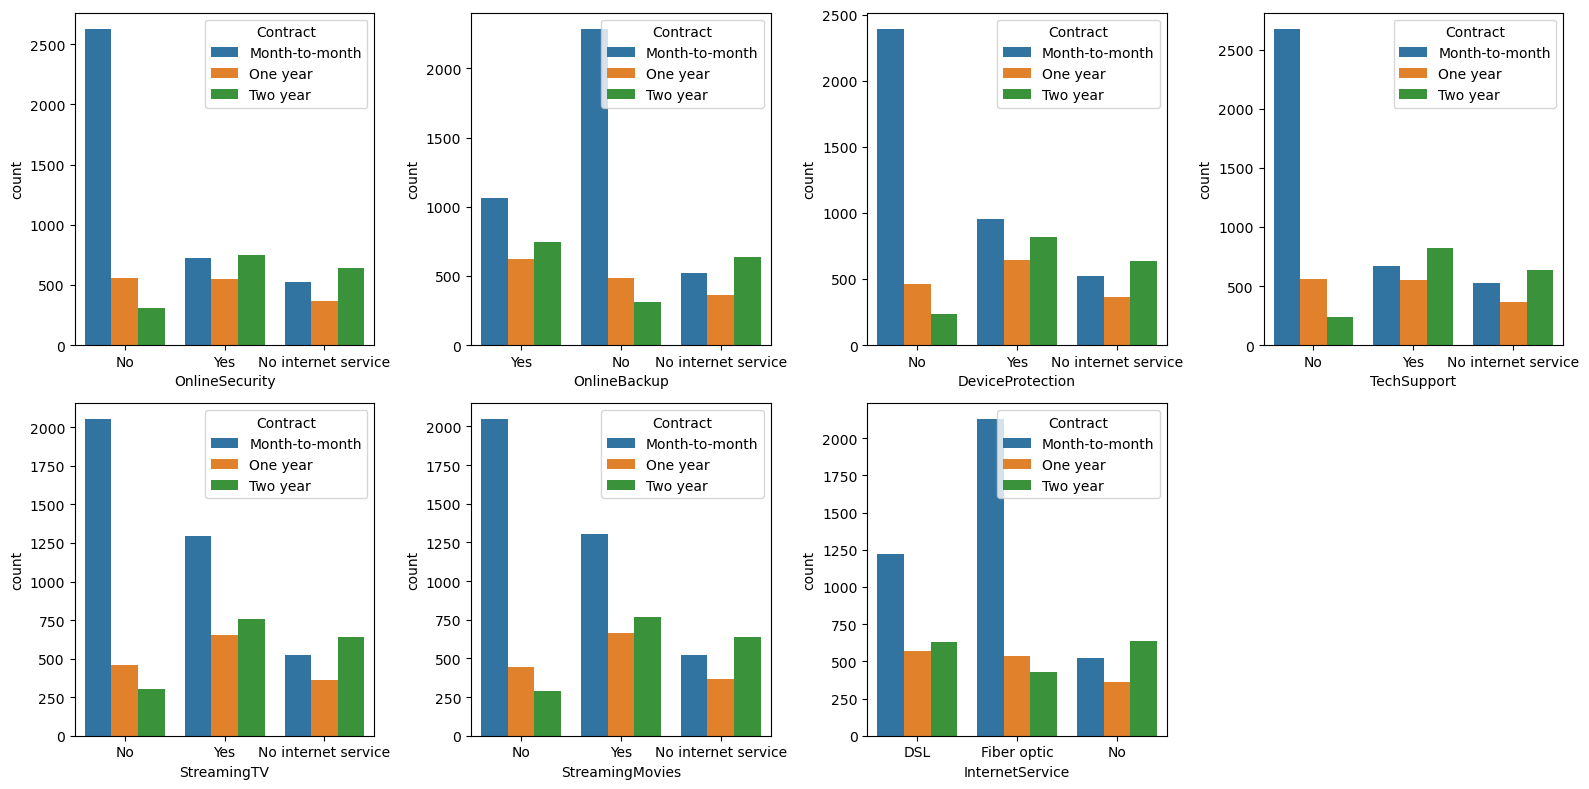

In [23]:
services=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport','StreamingTV', 'StreamingMovies','InternetService']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))  
axes_iterator = iter(axes.ravel()) 

for col in services:
    curr_ax = next(axes_iterator) 
    sns.countplot(data = df, x = col, hue ='Contract', ax=curr_ax)
plt.tight_layout()
    
for remaining_ax in axes_iterator:
    fig.delaxes(remaining_ax)
    
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\05_categorical_vs_target.png')
plt.show()


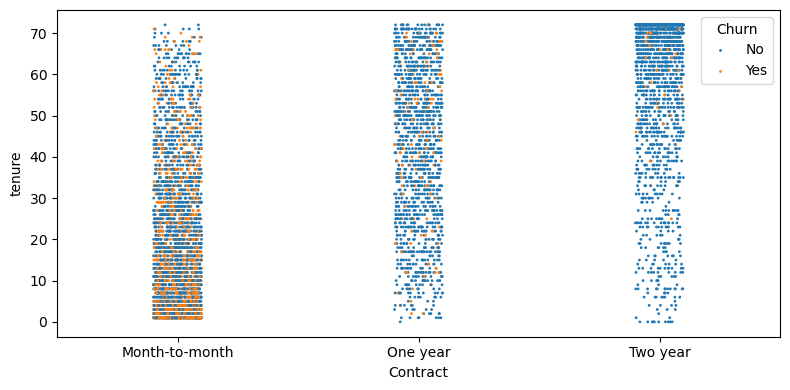

In [24]:
plt.figure(figsize = (8,4))
sns.stripplot(x="Contract", y="tenure", hue="Churn", data=df,size = 2)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\06_contract_vs_tenure.png')
plt.show()

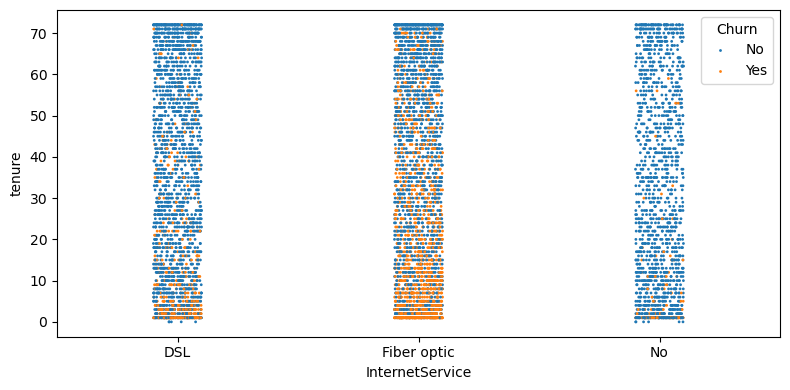

In [25]:
plt.figure(figsize = (8,4))
sns.stripplot(x="InternetService", y="tenure", hue="Churn", data=df,size = 2)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\07_internetservice_vs_tenure.png')
plt.show()

# 2.- Features Eingineering

- A significant proportion of customers on month-to-month contracts churn within a short period. Contrarily, those with high tenure typically transition to annual or biennial agreements, presenting a low rate of churning. Therefore, it may be valuable to construct a new variable identifying **high-risk customers**. This segment would be defined by the simultaneous presence of a month-to-month contract, a tenure of fewer than 12 to 16 months, and a fibre-optic internet subscription.

- Given that **TotalCharges** naturally escalates as customer tenure extends and, as previously stated, individuals exhibit a higher propensity to churn when monthly fees increase, it is valuable to *examine the ratio between monthly and total charges*. Consequently, new customers will display a ratio near 1, whereas longer-term clients should demonstrate a ratio that smoothly approaches zero. If a long-term customer exhibits a higher ratio, this correlates with an increased probability of churn.

- Furthermore, as the majority of churned customers subscribe to only a single service, whereas those utilizing multiple services demonstrate lower attrition rates, it may be convinient to construct a new variable representing the *total number of subscribed services per customer*.

In [26]:
df2 = df.copy(deep=True)
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport','StreamingTV', 'StreamingMovies']

In [27]:
df2['ChargesRatio'] = np.where((df['TotalCharges'] == 0),0,df['MonthlyCharges'] / (df['TotalCharges'])) 

In [28]:
df2['TotalServices'] = df[services].apply(lambda x: x.str.startswith('Yes').sum(),
                                         axis=1)
df2['TotalServices'] = np.where((df['InternetService'] != 'No'),df2['TotalServices']+1, df2['TotalServices']) 

In [29]:
df2['HighRiskCustomer'] = (df['tenure'] <= 12) & (df['Contract'] == 'Month-to-month') & (df['InternetService'] == 'Fiber optic')
df2['HighRiskCustomer'] = df2['HighRiskCustomer'].map({False: "No", True: "Yes"}) 

Visualizing the new variables behaviour:

In [30]:
new_num_cols = num_cols+['ChargesRatio','TotalServices']
print(new_num_cols)

['tenure', 'MonthlyCharges', 'TotalCharges', 'ChargesRatio', 'TotalServices']


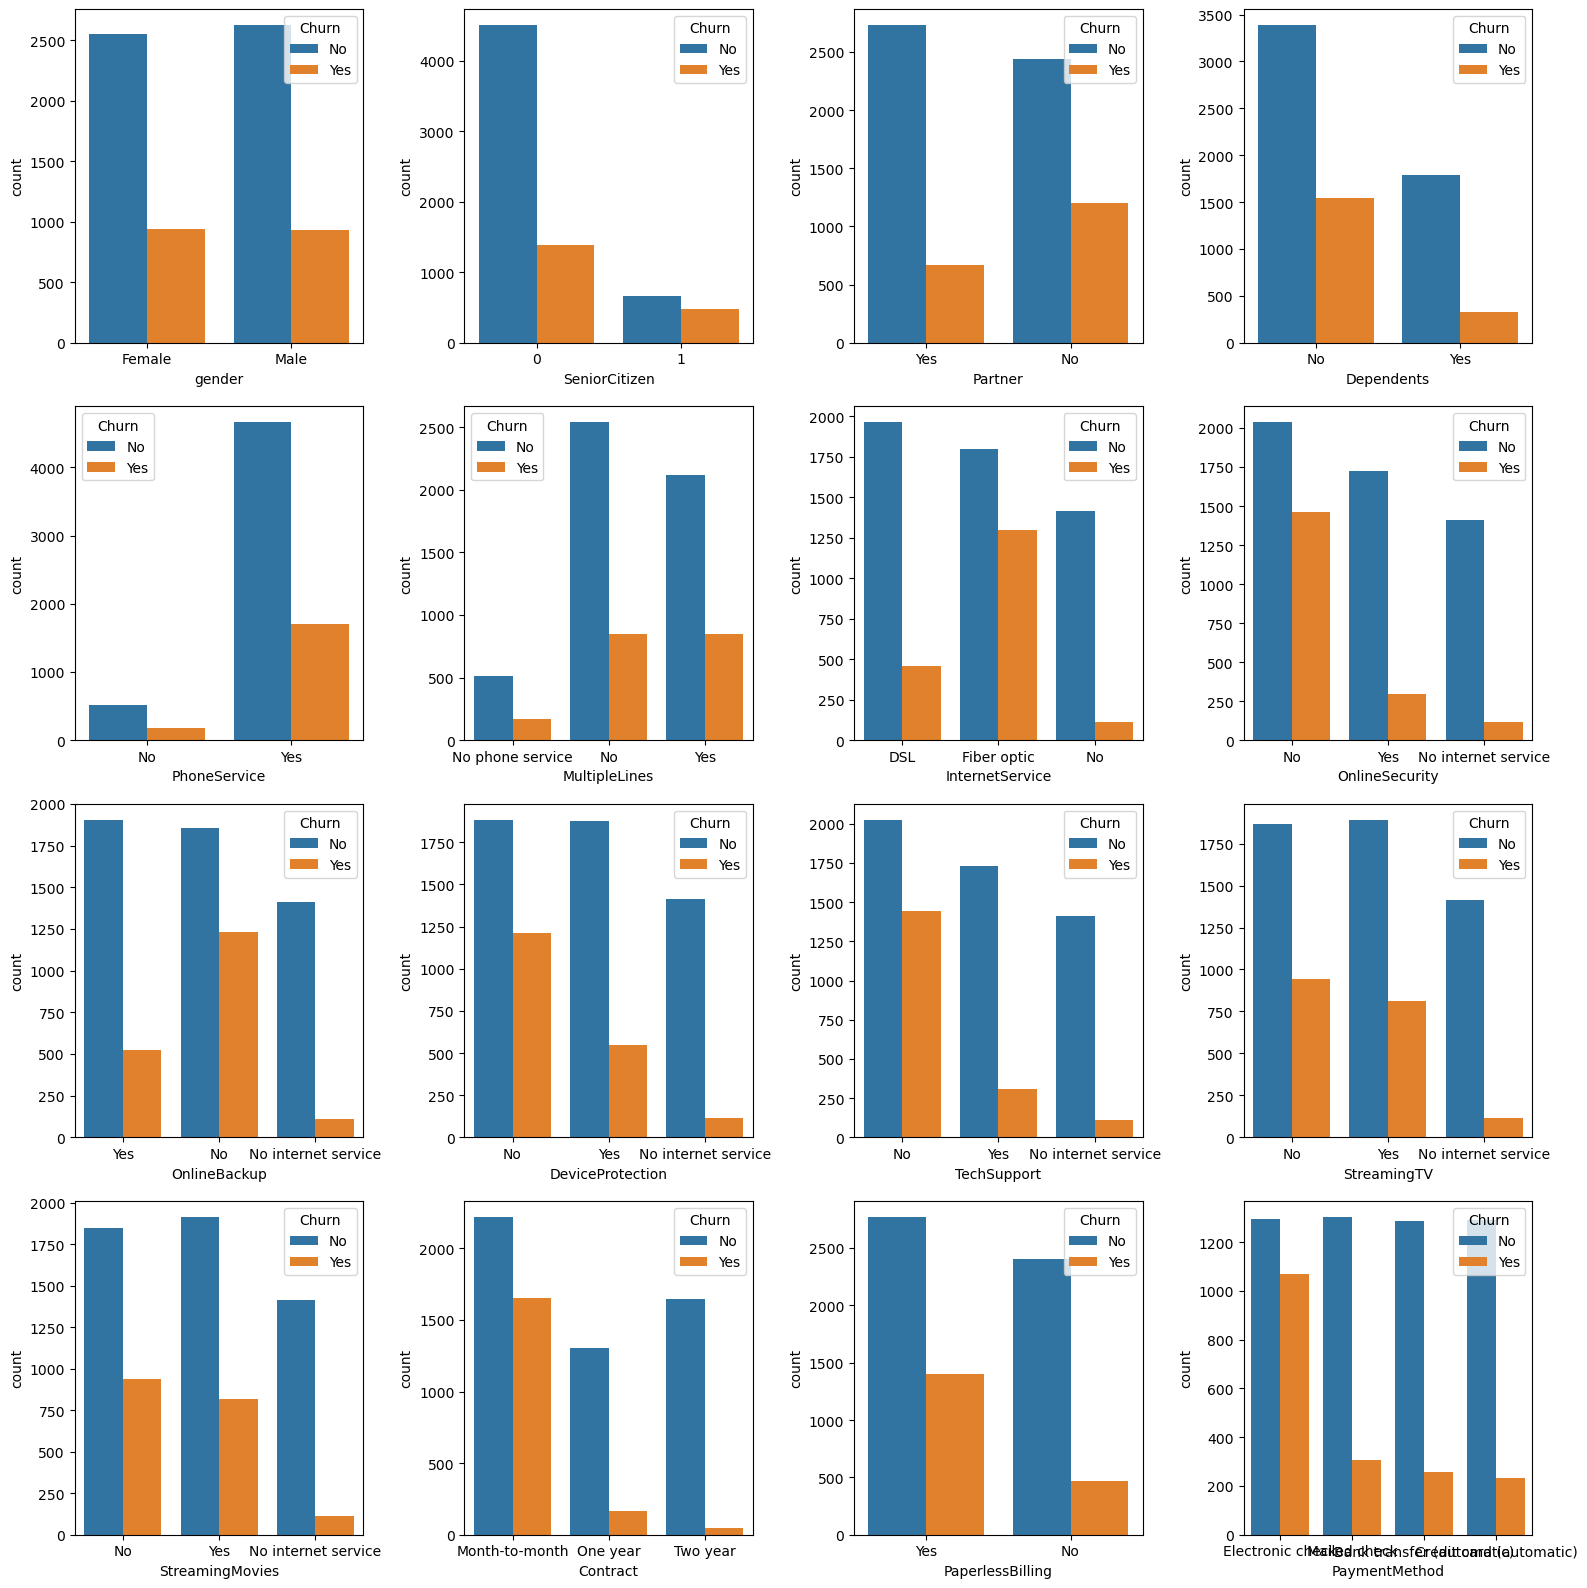

In [31]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))  
axes_iterator = iter(axes.ravel()) 

for col in cat_cols:
    curr_ax = next(axes_iterator) 
    sns.countplot(data = df, x = col, hue ='Churn', ax=curr_ax)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\05_categorical_vs_target.png')
plt.show()

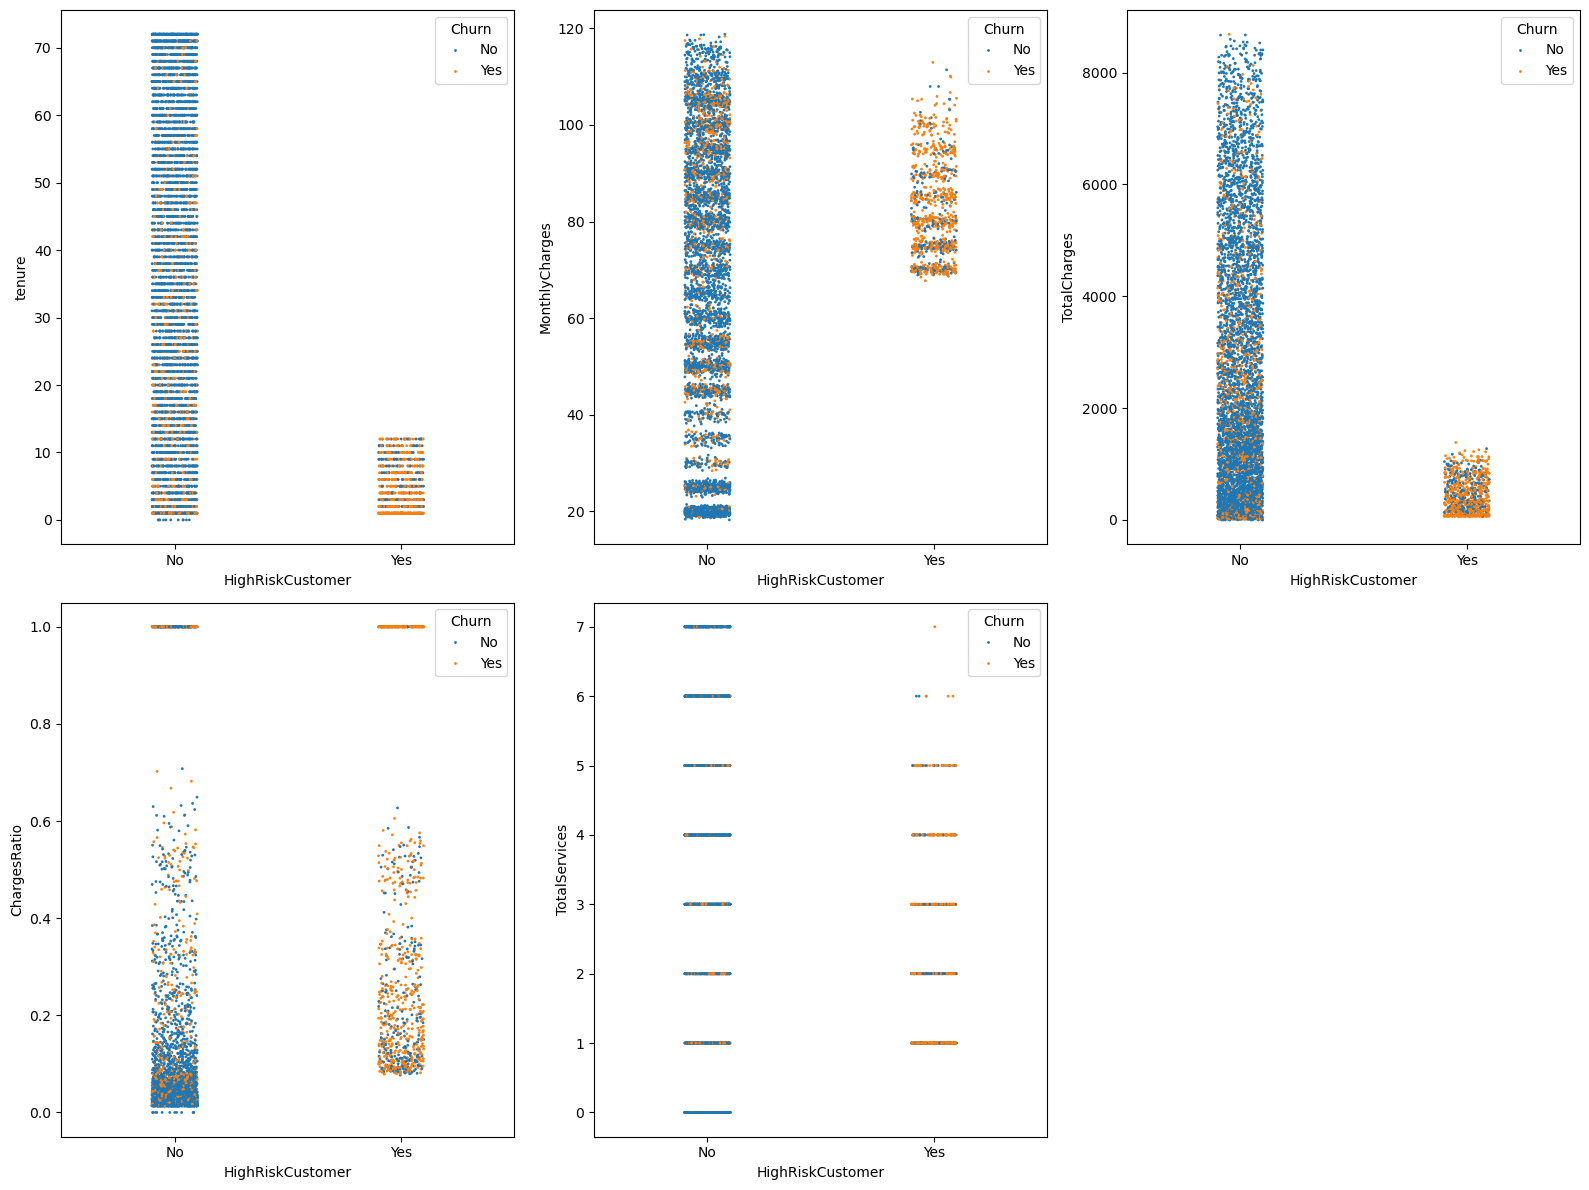

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))  
axes_iterator = iter(axes.ravel()) 

for col in new_num_cols:
    curr_ax = next(axes_iterator) 
    sns.stripplot(data = df2, x = 'HighRiskCustomer', y = col, hue = 'Churn',size = 2, ax=curr_ax)
plt.tight_layout()
for remaining_ax in axes_iterator:
    fig.delaxes(remaining_ax)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\08_highriskcustomer_vs_numerics.png')
plt.show()


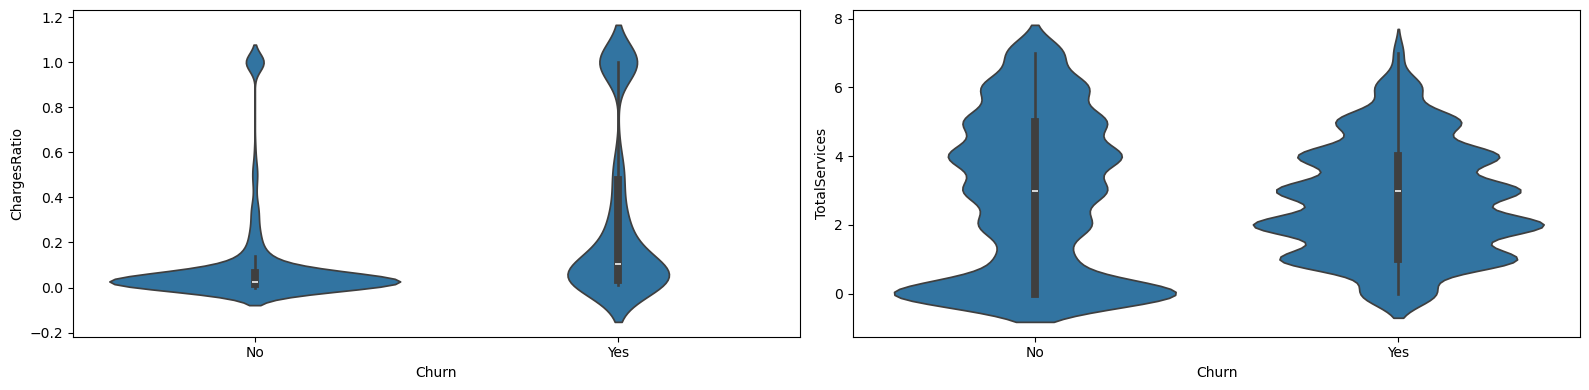

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))  
axes_iterator = iter(axes.ravel()) 

for col in ['ChargesRatio','TotalServices']:
    curr_ax = next(axes_iterator) 
    sns.violinplot(data = df2, x = 'Churn', y = col, ax=curr_ax)
plt.tight_layout()
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\09_newnumerics_vs_churn.png')
plt.show()

## 2.1.-  Correlation between variables

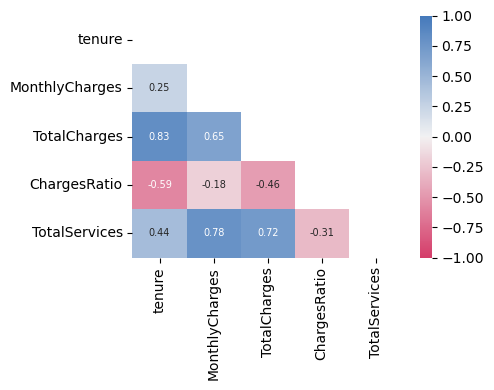

In [34]:
corrmat = df2[new_num_cols].corr()
mask= np.zeros_like(corrmat)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(corrmat,
            vmax=1, vmin=-1,
            annot=True, annot_kws={'fontsize':7},
            mask=mask,
            cmap=sns.diverging_palette(0,250,as_cmap=True),ax = ax)
plt.tight_layout()
plt.savefig(dp+'\\reports\\figures\\10_numericals_correlation.png')
plt.show()

**Tenure** and **TotalCharges** have a high positive correlation, since the longer the customer is subscribed to the service, the higher is the sum of their total charges throughout time.

Other correlations were explained when the new variables were created.

# 3.- Data Leakage

All variable information is available previous to the churn statement, so it won't be necessary to drop any other variable.

In [35]:
df2['Churn'] = df2.pop('Churn')

Saving new data file:

In [36]:
df2.to_csv(dp+'\\data\\Telco-Customer-Churn_processed.csv',index = False)